# ANOSIM and Mantel Test in R

## Overview

### ANOSIM (Analysis of Similarity)
ANOSIM tests whether dissimilarities **between** groups are greater than dissimilarities **within** groups. It ranks all pairwise dissimilarities and computes an R statistic comparing between- and within-group ranks.

| ANOSIM R | Interpretation |
|---|---|
| R ≈ 1 | Groups are completely separated |
| R ≈ 0 | No difference between within- and between-group dissimilarity |
| R < 0 | Within-group dissimilarity exceeds between-group (unusual) |
| R > 0.75 | Well-separated groups |
| R 0.5–0.75 | Overlapping but distinct |
| R 0.25–0.5 | Separated with considerable overlap |

### Mantel Test
The Mantel test tests the correlation between two distance/dissimilarity matrices. It answers: "Are sites that are more ecologically similar also more similar in their environment?" or "Does geographic distance predict community dissimilarity?"

## ANOSIM vs. PERMANOVA

| | ANOSIM | PERMANOVA |
|---|---|---|
| Test type | Rank-based | Distance-based F-ratio |
| Multi-factor designs | No | Yes |
| Effect size | R statistic (bounded -1 to 1) | R² (proportion of variance) |
| Sensitivity to dispersion | High | Moderate |
| Recommendation | Supplementary; PERMANOVA preferred | Primary test |

> **When to use ANOSIM:** As a supplementary check alongside PERMANOVA, or when comparing with older literature that used ANOSIM. For primary analyses, PERMANOVA (`adonis2`) is preferred.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(vegan)   # anosim(), mantel(), vegdist()

set.seed(42)

# ── Community matrix and environmental data ───────────────────────────────────
n_sites <- 45; n_sp <- 20
habitat <- rep(c("reference", "degraded", "restored"), each = 15)

ref_means  <- c(8,7,6,5,5,4,3,3,2,2,1,1,1,0,0,0,0,0,0,0)
deg_means  <- c(0,0,1,1,2,3,4,5,6,7,8,6,4,3,2,1,1,1,0,0)
rest_means <- c(4,4,4,3,3,3,3,2,2,2,2,2,1,1,1,1,0,0,0,0)

sim_comm <- function(n, mu, sd = 0.7)
  t(replicate(n, pmax(round(exp(rnorm(n_sp, log(mu + 0.1), sd))), 0L)))

comm_mat <- rbind(sim_comm(15, ref_means),
                  sim_comm(15, deg_means, sd = 1.0),
                  sim_comm(15, rest_means, sd = 0.8))
rownames(comm_mat) <- paste0("site", 1:n_sites)
colnames(comm_mat) <- paste0("sp",   1:n_sp)

env_df <- tibble(
  site    = paste0("site", 1:n_sites),
  habitat = factor(habitat, levels = c("reference", "degraded", "restored")),
  pH      = c(rnorm(15, 7.8, 0.3), rnorm(15, 6.5, 0.6), rnorm(15, 7.2, 0.4)),
  nitrate = c(rnorm(15, 0.5, 0.2), rnorm(15, 3.5, 1.0), rnorm(15, 1.5, 0.5)),
  # Simulated spatial coordinates
  lon     = runif(n_sites, -70, -65),
  lat     = runif(n_sites,  42,  47)
)

dist_bray <- vegan::vegdist(comm_mat, method = "bray")

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'vegan' was built under R version 4.4.3"
Loading required package: permute



---

## ANOSIM


Call:
vegan::anosim(x = dist_bray, grouping = env_df$habitat, permutations = 999) 
Dissimilarity: bray 

ANOSIM statistic R: 0.6309 
      Significance: 0.001 

Permutation: free
Number of permutations: 999

Upper quantiles of permutations (null model):
   90%    95%  97.5%    99% 
0.0400 0.0594 0.0806 0.1009 

Dissimilarity ranks between and within classes:
            0%    25%   50%   75%  100%   N
Between    7.0 404.75 631.5 814.5 990.0 675
reference  2.0  61.00 150.5 259.0 549.5 105
degraded  23.5 265.00 402.0 573.0 966.0 105
restored   1.0 114.00 228.0 352.0 733.0 105


ANOSIM R = 0.6309, p = 0.0010
Interpretation: Overlapping but distinct groups


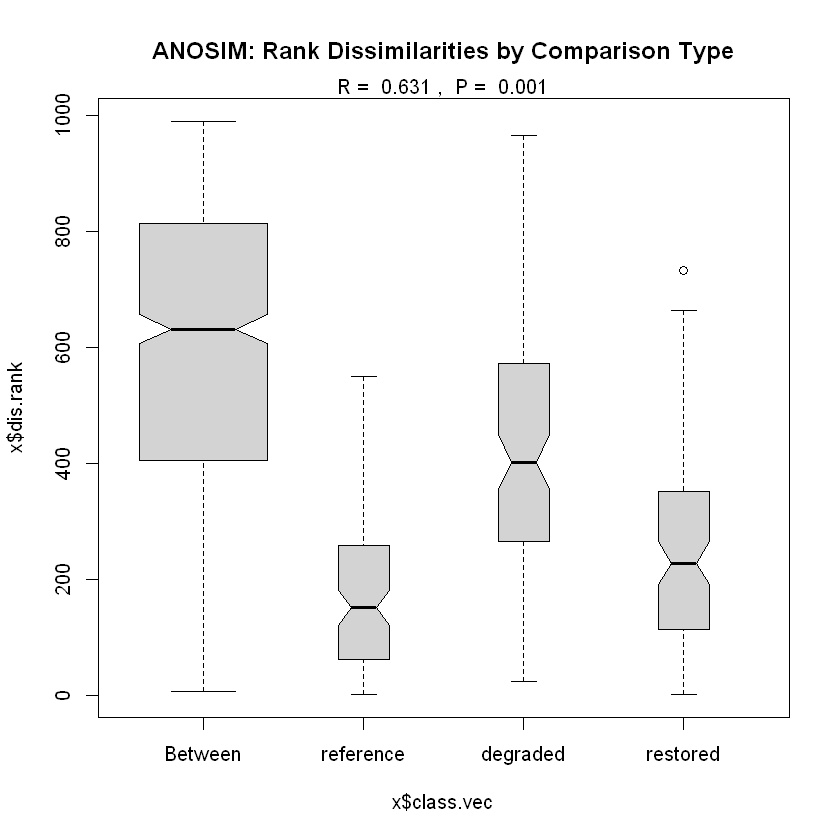

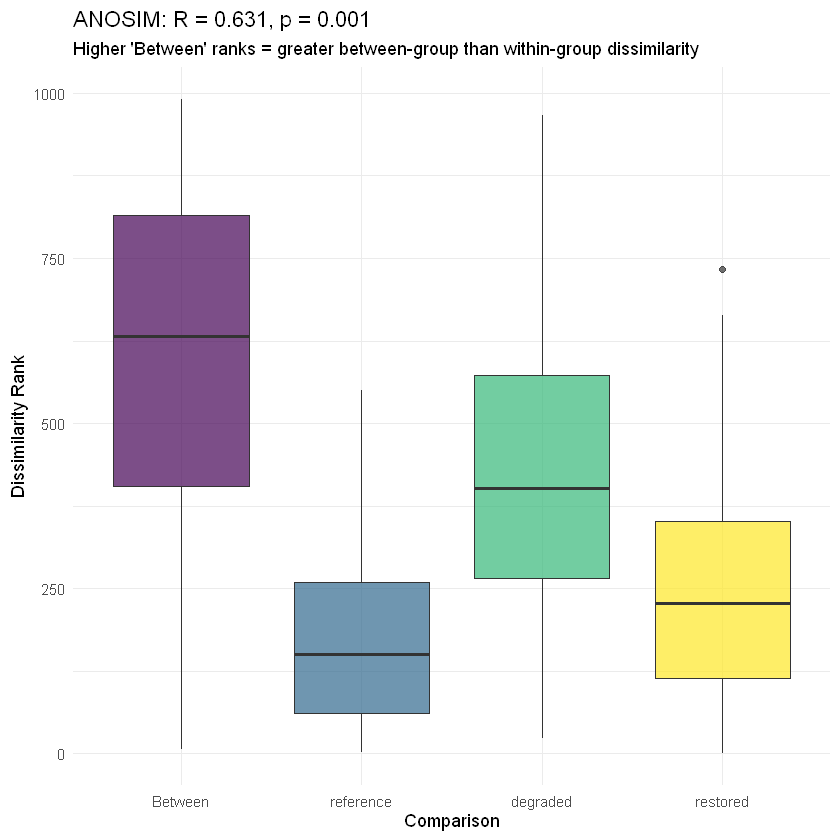

In [2]:
# ── One-way ANOSIM ────────────────────────────────────────────────────────────
anosim_result <- vegan::anosim(
  dist_bray,
  grouping     = env_df$habitat,
  permutations = 999
)
summary(anosim_result)
# Key output:
#   ANOSIM statistic R: effect size
#   Significance: permutation p-value

cat(sprintf("\nANOSIM R = %.4f, p = %.4f\n",
            anosim_result$statistic,
            anosim_result$signif))

# ── Interpretation ────────────────────────────────────────────────────────────
r <- anosim_result$statistic
cat(sprintf("Interpretation: %s\n",
  dplyr::case_when(
    r > 0.75 ~ "Well-separated groups",
    r > 0.50 ~ "Overlapping but distinct groups",
    r > 0.25 ~ "Separated with considerable overlap",
    r > 0    ~ "Groups barely distinguishable",
    TRUE     ~ "No separation (or within > between dissimilarity)"
  )))

# ── Default plot: rank dissimilarities by comparison type ─────────────────────
plot(anosim_result, main = "ANOSIM: Rank Dissimilarities by Comparison Type")
# Between: between-group pairs — should have higher ranks (more dissimilar)
# Within each group: within-group pairs — should have lower ranks
# Good separation: 'Between' box clearly higher than within-group boxes

# ── ggplot2 version ───────────────────────────────────────────────────────────
anosim_df <- tibble(
  rank       = anosim_result$dis.rank,
  comparison = anosim_result$class.vec
)

ggplot(anosim_df, aes(x = comparison, y = rank, fill = comparison)) +
  geom_boxplot(alpha = 0.7) +
  scale_fill_viridis_d() +
  labs(title = sprintf("ANOSIM: R = %.3f, p = %.3f",
                       anosim_result$statistic,
                       anosim_result$signif),
       subtitle = "Higher 'Between' ranks = greater between-group than within-group dissimilarity",
       x = "Comparison", y = "Dissimilarity Rank") +
  theme_minimal() + theme(legend.position = "none")

### Pairwise ANOSIM

In [3]:
# ── Manual pairwise ANOSIM ────────────────────────────────────────────────────
pairs <- combn(levels(env_df$habitat), 2, simplify = FALSE)

pairwise_anosim <- map_dfr(pairs, function(p) {
  idx   <- env_df$habitat %in% p
  d_sub <- vegan::vegdist(comm_mat[idx, ], method = "bray")
  g_sub <- droplevels(env_df$habitat[idx])
  res   <- vegan::anosim(d_sub, g_sub, permutations = 999)
  tibble(
    comparison = paste(p, collapse = " vs. "),
    R   = round(res$statistic, 4),
    p   = res$signif
  )
}) %>%
  mutate(p_adj = round(p.adjust(p, method = "BH"), 4))

print(pairwise_anosim)

# A tibble: 3 × 4
  comparison                 R     p p_adj
  <chr>                  <dbl> <dbl> <dbl>
1 reference vs. degraded 0.910 0.001 0.001
2 reference vs. restored 0.324 0.001 0.001
3 degraded vs. restored  0.774 0.001 0.001


---

## Mantel Test

Tests the correlation between two distance matrices. Classic uses: ecology–environment correlation (do similar communities live in similar environments?), isolation by distance (does geographic distance predict genetic differentiation?).

In [4]:
# ── Environmental distance matrix ─────────────────────────────────────────────
env_vars <- env_df %>% select(pH, nitrate) %>% scale()
dist_env <- dist(env_vars, method = "euclidean")

# ── Mantel test: community ~ environment ─────────────────────────────────────
mantel_result <- vegan::mantel(
  dist_bray,      # community dissimilarity
  dist_env,       # environmental distance
  method       = "pearson",   # or "spearman" for rank-based
  permutations = 999
)
print(mantel_result)
# r: Mantel correlation coefficient
# p-value: permutation significance

# ── Geographic (spatial) distance matrix ─────────────────────────────────────
geo_coords <- env_df %>% select(lon, lat)
dist_geo   <- dist(geo_coords)

mantel_geo <- vegan::mantel(
  dist_bray,
  dist_geo,
  method       = "pearson",
  permutations = 999
)
cat(sprintf("\nMantel test (community ~ geography): r = %.4f, p = %.4f\n",
            mantel_geo$statistic, mantel_geo$signif))

# ── Partial Mantel test: community ~ environment, controlling for geography ───
# Is the ecology–environment correlation independent of spatial structure?
mantel_partial <- vegan::mantel.partial(
  dist_bray,
  dist_env,
  dist_geo,       # matrix to control for
  method       = "pearson",
  permutations = 999
)
print(mantel_partial)


Mantel statistic based on Pearson's product-moment correlation 

Call:
vegan::mantel(xdis = dist_bray, ydis = dist_env, method = "pearson",      permutations = 999) 

Mantel statistic r: 0.5387 
      Significance: 0.001 

Upper quantiles of permutations (null model):
   90%    95%  97.5%    99% 
0.0744 0.1056 0.1334 0.1639 
Permutation: free
Number of permutations: 999


Mantel test (community ~ geography): r = 0.0303, p = 0.2930

Partial Mantel statistic based on Pearson's product-moment correlation 

Call:
vegan::mantel.partial(xdis = dist_bray, ydis = dist_env, zdis = dist_geo,      method = "pearson", permutations = 999) 

Mantel statistic r: 0.5393 
      Significance: 0.001 

Upper quantiles of permutations (null model):
   90%    95%  97.5%    99% 
0.0784 0.1068 0.1336 0.1656 
Permutation: free
Number of permutations: 999



### Visualizing the Mantel Relationship

`geom_smooth()` using formula = 'y ~ x'


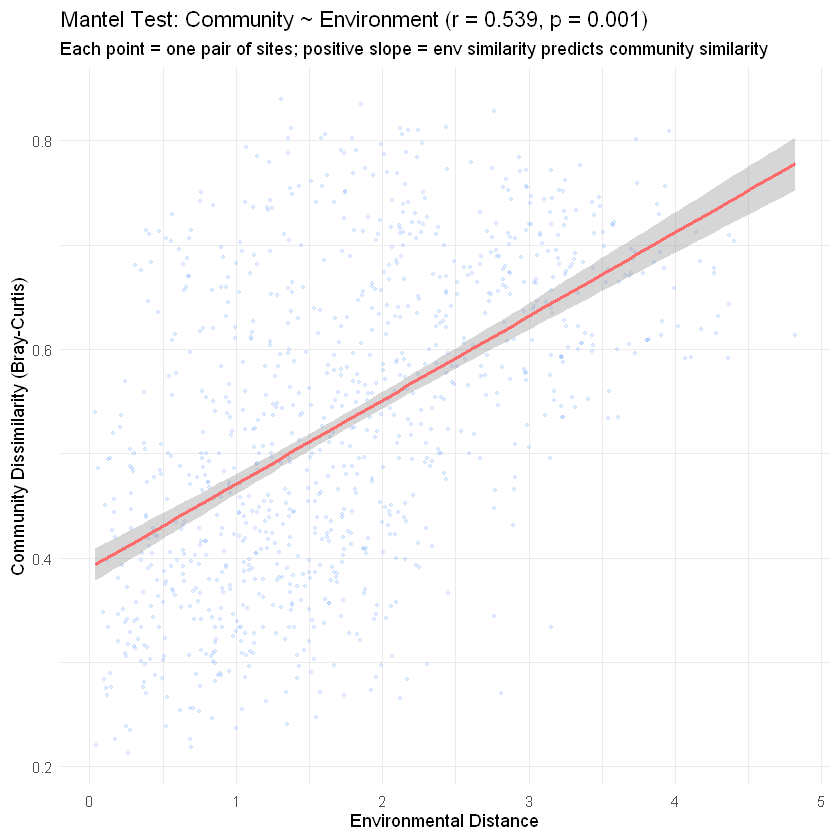

In [5]:
# ── Scatter plot of pairwise distances ────────────────────────────────────────
mantel_df <- tibble(
  comm_dist = as.vector(dist_bray),
  env_dist  = as.vector(dist_env)
)

ggplot(mantel_df, aes(x = env_dist, y = comm_dist)) +
  geom_point(alpha = 0.15, size = 0.8, color = "#4a8fff") +
  geom_smooth(method = "lm", se = TRUE, color = "#ff6b6b", linewidth = 1) +
  labs(
    title = sprintf("Mantel Test: Community ~ Environment (r = %.3f, p = %.3f)",
                    mantel_result$statistic, mantel_result$signif),
    subtitle = "Each point = one pair of sites; positive slope = env similarity predicts community similarity",
    x = "Environmental Distance",
    y = "Community Dissimilarity (Bray-Curtis)"
  ) +
  theme_minimal()

---

## Reporting Results

In [6]:
# Standard ANOSIM reporting:
# "ANOSIM indicated significant differences in community composition among
#  habitat types (R = X.XXX, p = .XXX, 999 permutations). Pairwise
#  comparisons (BH-corrected) showed reference sites were distinct from
#  degraded (R = X.XX, p_adj = .XXX) and restored (R = X.XX, p_adj = .XXX)
#  sites; degraded and restored sites did not differ significantly
#  (R = X.XX, p_adj = .XXX)."

# Standard Mantel reporting:
# "Community compositional dissimilarity was significantly correlated with
#  environmental distance (Mantel r = X.XXX, p = .XXX, 999 permutations),
#  indicating that environmentally similar sites supported more similar
#  invertebrate assemblages. A partial Mantel test controlling for
#  geographic distance confirmed this relationship remained significant
#  (partial r = X.XXX, p = .XXX), suggesting the community–environment
#  relationship is not solely attributable to spatial autocorrelation."

---

## Common Pitfalls

**1. Preferring ANOSIM over PERMANOVA**  
ANOSIM cannot handle multiple factors, covariates, or interactions. Its R statistic is also more sensitive to dispersion heterogeneity than PERMANOVA's pseudo-F. Use PERMANOVA as the primary test; ANOSIM is supplementary.

**2. Interpreting a non-significant Mantel test as no ecology–environment relationship**  
The Mantel test only detects linear (or rank-order) correlations between distance matrices. A non-linear relationship, or one that operates at a different spatial scale, can be missed. Pair with dbRDA for a more complete analysis.

**3. Not using a partial Mantel when spatial autocorrelation is plausible**  
Nearby sites tend to be both environmentally similar and compositionally similar simply due to proximity. Always test the partial Mantel (controlling for geographic distance) to confirm the ecology–environment relationship is not just spatial autocorrelation.

**4. Not correcting pairwise ANOSIM tests for multiple comparisons**  
Each pairwise test inflates family-wise error. Apply BH or Bonferroni correction.

**5. Using the Mantel test to infer causation**  
The Mantel test shows correlation between distance matrices — it does not show that environment *causes* community differences. Use dbRDA or constrained ordination to more directly model the environment–community relationship.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*